# Robomimic Full Dataset Failure Recognition & Recovery Training
This notebook trains the `FailureRecognizer` on the complete robomimic dataset.
It splits the data into train/val sets, trains the model, and then evaluates
the recovery capabilities on unseen validation trajectories.

In [1]:
import os
import sys
import h5py
import torch
import numpy as np
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML, display
import imageio

# Ensure the a2l-pr package is in the path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

from a2l_pr.adapters.robomimic import RobomimicAdapter  
from a2l_pr.perturbations.generator import PerturbationGenerator, PerturbationType
from a2l_pr.learning import FailureRecoveryDataset, FailureRecoveryTrainer
from a2l_pr.models import FailureRecognizer
from a2l_pr.config.config import ConfigManager

try:
    import robomimic.utils.obs_utils as ObsUtils
    import robomimic.utils.env_utils as EnvUtils
    import robomimic.utils.file_utils as FileUtils
    HAS_ROBOMIMIC = True
except ImportError:
    print("robomimic not found in environment, video rendering will be skipped.")
    HAS_ROBOMIMIC = False

I0000 00:00:1777674711.293048 1199462 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777674711.317184 1199462 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


KeyboardInterrupt: 

## 1. Configuration & Dataset Iteration

In [ ]:
robomimic_hdf5_path = os.path.abspath(os.path.join(
    os.getcwd(), "..", "..", "robomimic", "robomimic", "datasets", "square", "ph", "low_dim_v15.hdf5"
))

config_path = os.path.abspath(os.path.join(os.getcwd(), "..", "perturbation_config.yaml"))
config_mgr = ConfigManager.from_yaml(config_path)

def load_robomimic_trajectory(hdf5_path, demo_key="demo_0"):
    """Loads a single trajectory dictionary from a standard robomimic HDF5 file."""
    f = h5py.File(hdf5_path, 'r')
    demo_grp = f["data"][demo_key]
    obs_grp = demo_grp["obs"]
    
    trajectory = {
        'actions': demo_grp["actions"][:],
        'observations': {}
    }
    for key in obs_grp.keys():
        trajectory['observations'][key] = obs_grp[key][:]
    f.close()
    return trajectory

def extract_learning_sample(traj_dict, failure_type_id, fsm_id=0, rec_params=None):
    if rec_params is None:
        rec_params = np.zeros(7)
        
    actions = traj_dict['actions']
    obs = traj_dict['observations']
    
    if 'agentview_image' in obs:
        imgs = obs['agentview_image']
    else:
        # Fallback to random if not found
        imgs = np.random.randint(0, 255, (len(actions), 84, 84, 3), dtype=np.uint8)
        
    num_frames = 3
    if len(imgs) >= num_frames:
        last_frames = imgs[-num_frames:]
    else:
        last_frames = np.pad(imgs, ((num_frames - len(imgs), 0), (0,0), (0,0), (0,0)), mode='edge')
        
    last_frames = np.transpose(last_frames, (0, 3, 1, 2)).astype(np.float32) / 255.0
    
    num_act = 2
    if len(actions) >= num_act:
        last_actions = actions[-num_act:]
    else:
        last_actions = np.pad(actions, ((num_act - len(actions), 0), (0,0)), mode='edge')
        
    return {
        'frames': last_frames,
        'actions': last_actions.astype(np.float32),
        'failure_type_id': failure_type_id,
        'fsm_id': fsm_id,
        'recovery_params': rec_params.astype(np.float32)
    }

## 2. Build Dataset over All Trajectories

In [ ]:
print(f"Loading dataset from: {robomimic_hdf5_path}")
f = h5py.File(robomimic_hdf5_path, 'r')
all_demos = list(f["data"].keys())
f.close()

# We might limit to a subset (e.g., 50 trajectories) to save time, or use all
# For a full test, let's use all_demos.
# Uncomment the line below to use a smaller subset if training takes too long.
# all_demos = all_demos[:50] 

random.seed(42)
random.shuffle(all_demos)
split_idx = int(0.8 * len(all_demos))
train_demos = all_demos[:split_idx]
val_demos = all_demos[split_idx:]

print(f"Total Demos: {len(all_demos)} | Train: {len(train_demos)} | Val: {len(val_demos)}")

adapter = RobomimicAdapter()
generator = PerturbationGenerator()

perturbation_types = [
    PerturbationType.UNDERREACH_IDLE,
    PerturbationType.PREMATURE_CLOSE,
    PerturbationType.LATERAL_DRIFT,
    PerturbationType.PREMATURE_OPEN
]

def generate_records_from_demos(demo_list, desc="Processing"):
    records = []
    # Store one validation dictionary for visualization later
    vis_dict = None 
    
    for demo_key in tqdm(demo_list, desc=desc):
        raw_traj = load_robomimic_trajectory(robomimic_hdf5_path, demo_key=demo_key)
        traj = adapter.load(raw_traj)
        
        # Inject config defaults
        dataset_defaults = config_mgr.get_dataset_defaults(traj['metadata'].get('dataset_type', 'ph'))
        traj['metadata'].update(dataset_defaults)
        traj['metadata'].update(config_mgr.get_perturbation_config())
        
        # Add Original (No Failure)
        records.append(extract_learning_sample(traj, failure_type_id=0))
        
        # Save the very first validation trajectory we process for our video render later
        if vis_dict is None and desc == "Validation":
            vis_dict = {
                'demo_key': demo_key,
                'original': traj,
                'perturbations': {}
            }
        
        # Add Perturbations
        for idx, p_type in enumerate(perturbation_types, start=1):
            res = generator.apply_perturbation(traj, p_type, severity=0.5)
            if res is not None:
                # Target recovery parameters
                rec_params = np.zeros(7)
                if p_type == PerturbationType.UNDERREACH_IDLE:
                    rec_params[0] = 0.05
                elif p_type == PerturbationType.PREMATURE_CLOSE:
                    rec_params[6] = -1.0
                elif p_type == PerturbationType.LATERAL_DRIFT:
                    rec_params[1] = -0.05
                elif p_type == PerturbationType.PREMATURE_OPEN:
                    rec_params[6] = 1.0
                    
                records.append(extract_learning_sample(
                    res.perturbed_trajectory, 
                    failure_type_id=idx,
                    fsm_id=min(idx, 2), 
                    rec_params=rec_params
                ))
                
                if vis_dict is not None and demo_key == vis_dict['demo_key']:
                    vis_dict['perturbations'][p_type.name] = res.perturbed_trajectory
                    
    return records, vis_dict

train_records, _ = generate_records_from_demos(train_demos, desc="Training")
val_records, vis_dict = generate_records_from_demos(val_demos, desc="Validation")

train_dataset = FailureRecoveryDataset(train_records)
val_dataset = FailureRecoveryDataset(val_records)

Loading dataset from: /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/datasets/square/ph/low_dim_v15.hdf5
Total Demos: 200 | Train: 160 | Val: 40


Training:   0%|          | 0/160 [00:00<?, ?it/s]

Validation: 100%|██████████| 40/40 [00:00<00:00, 54.53it/s]


## 3. Train the Model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = FailureRecognizer(
    num_frames=3,
    action_dim=7,
    num_action_history=2,
    num_failure_types=len(perturbation_types) + 1,
    recovery_param_dim=7,
    num_fsm_templates=3,
    vision_encoder_type="resnet18",
    hidden_dim=256
)

# Optional: Add class weights to penalize the "no failure" class less
# since it appears less frequently than all failures combined.
class_weights = [1.0] + [2.0] * len(perturbation_types)

trainer = FailureRecoveryTrainer(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=32,
    lr=1e-3,
    device=device,
    weights=class_weights
)

epochs = 15
best_val_loss = float('inf')

print("Starting Full Dataset Training...")
for epoch in range(1, epochs + 1):
    train_loss = trainer.train_epoch()
    val_metrics = trainer.evaluate()
    
    val_loss = val_metrics['val_loss']
    val_acc = val_metrics['val_failure_acc']
    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_failure_recognizer.pth")

print("Training Complete! Best model saved.")

/home/griffing52/miniconda3/envs/a2l/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/griffing52/miniconda3/envs/a2l/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Using device: cuda
Starting Full Dataset Training...


Evaluating: 100%|██████████| 7/7 [00:00<00:00, 187.08it/s]


Epoch 1 | Train Loss: 3.0583 | Val Loss: 3.0782 | Val Acc: 23.00%


Evaluating: 100%|██████████| 7/7 [00:00<00:00, 290.19it/s]


...

Epoch 13 | Train Loss: 0.2117 | Val Loss: 6.2973 | Val Acc: 21.50%


Evaluating: 100%|██████████| 7/7 [00:00<00:00, 259.35it/s]


Epoch 14 | Train Loss: 0.1505 | Val Loss: 7.8086 | Val Acc: 22.00%


Evaluating: 100%|██████████| 7/7 [00:00<00:00, 281.12it/s]

Epoch 15 | Train Loss: 0.2052 | Val Loss: 6.7258 | Val Acc: 21.00%
Training Complete! Best model saved.


## 4. 3D Plot Visualization
Let's plot the spatial differences between the original trajectory and the generated failures.


--- 3D Trajectory Plots for demo_176 ---


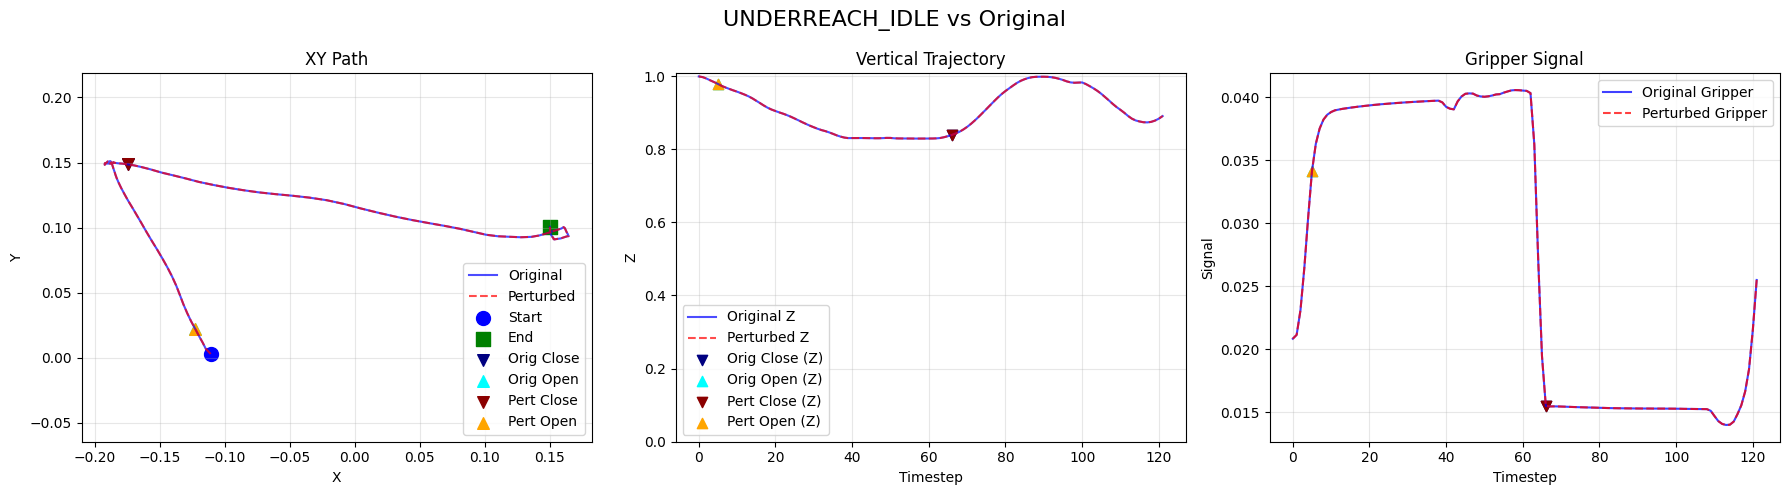

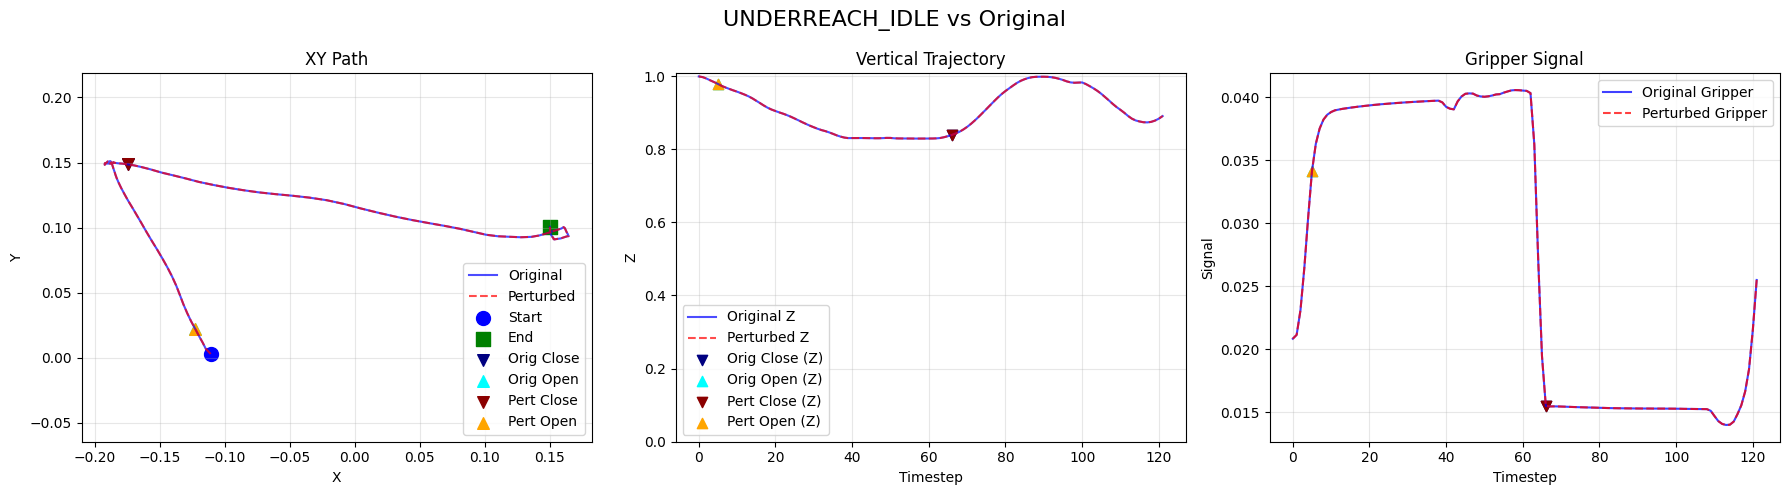

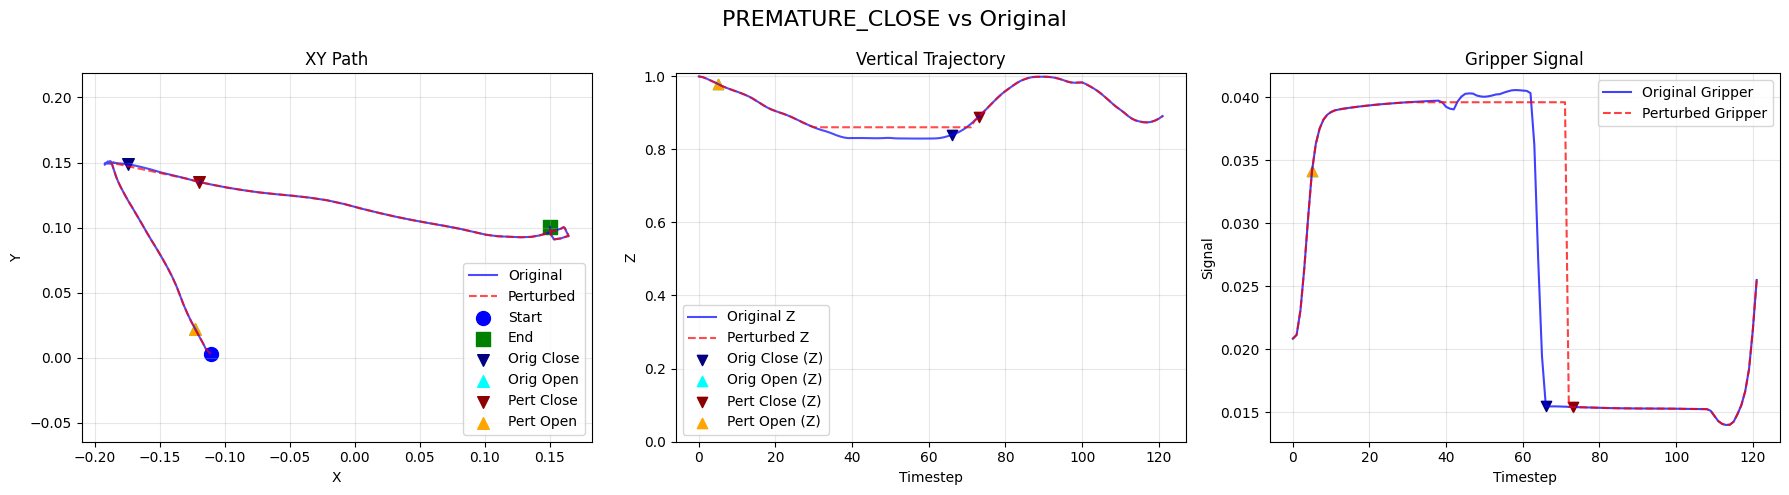

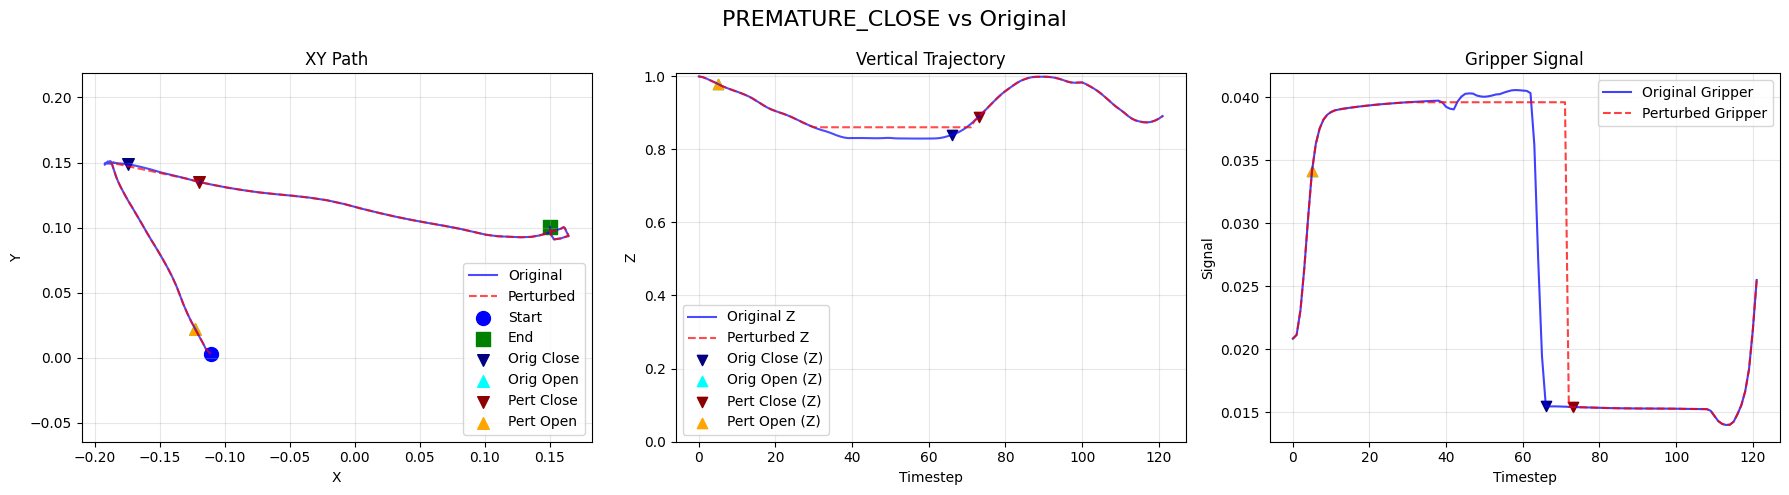

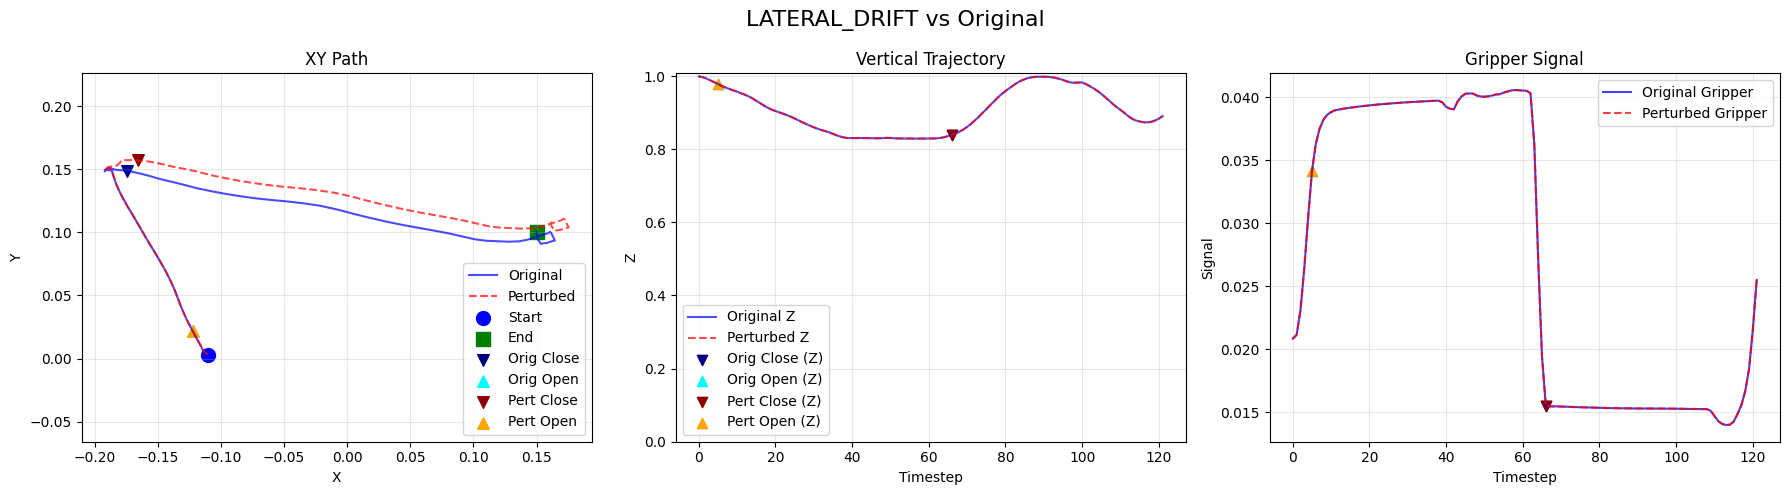

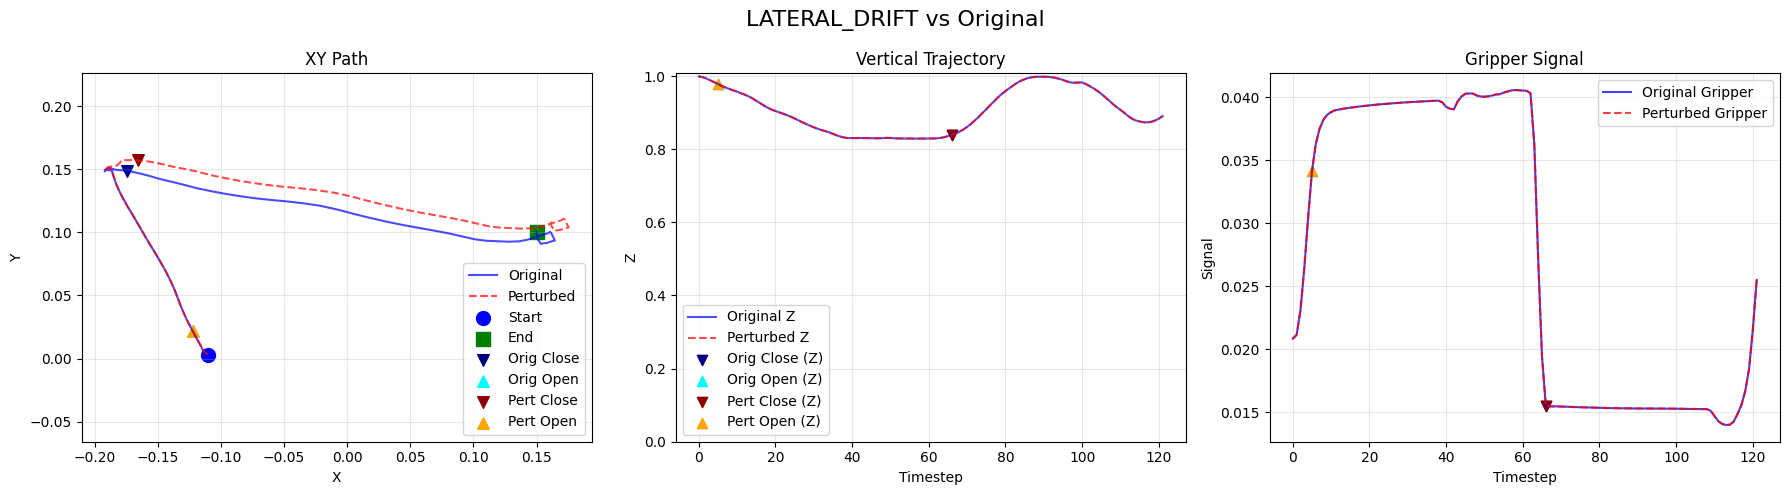

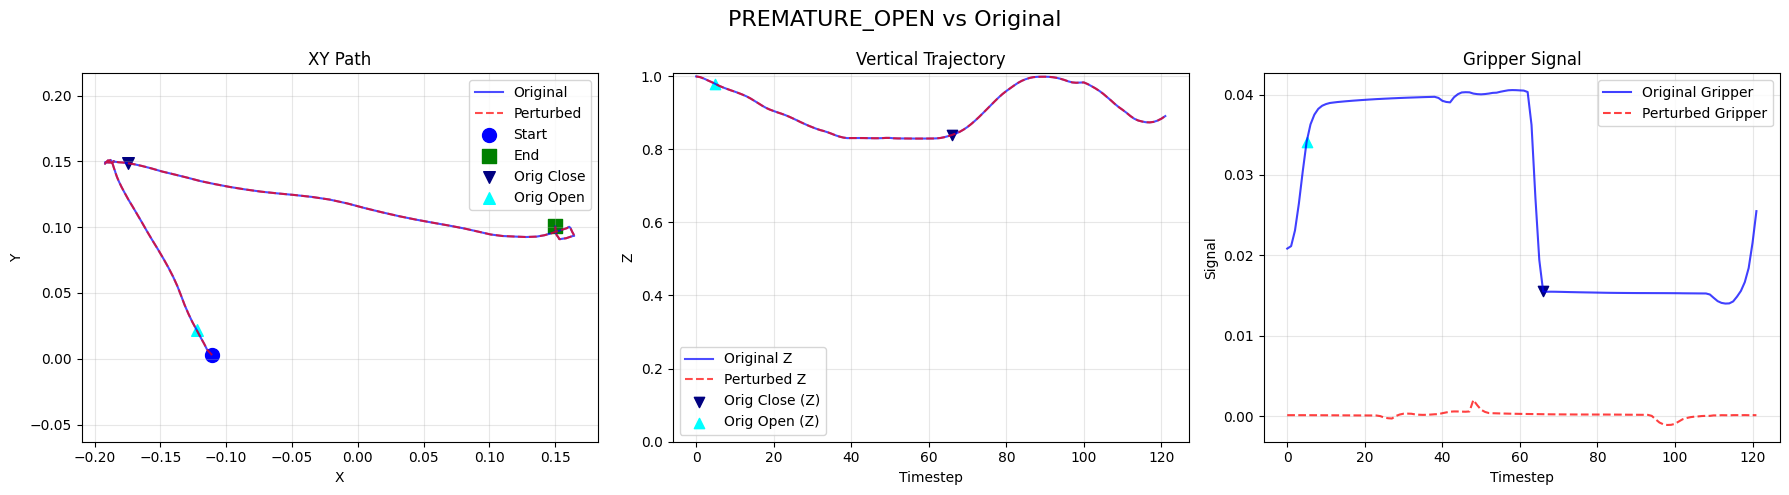

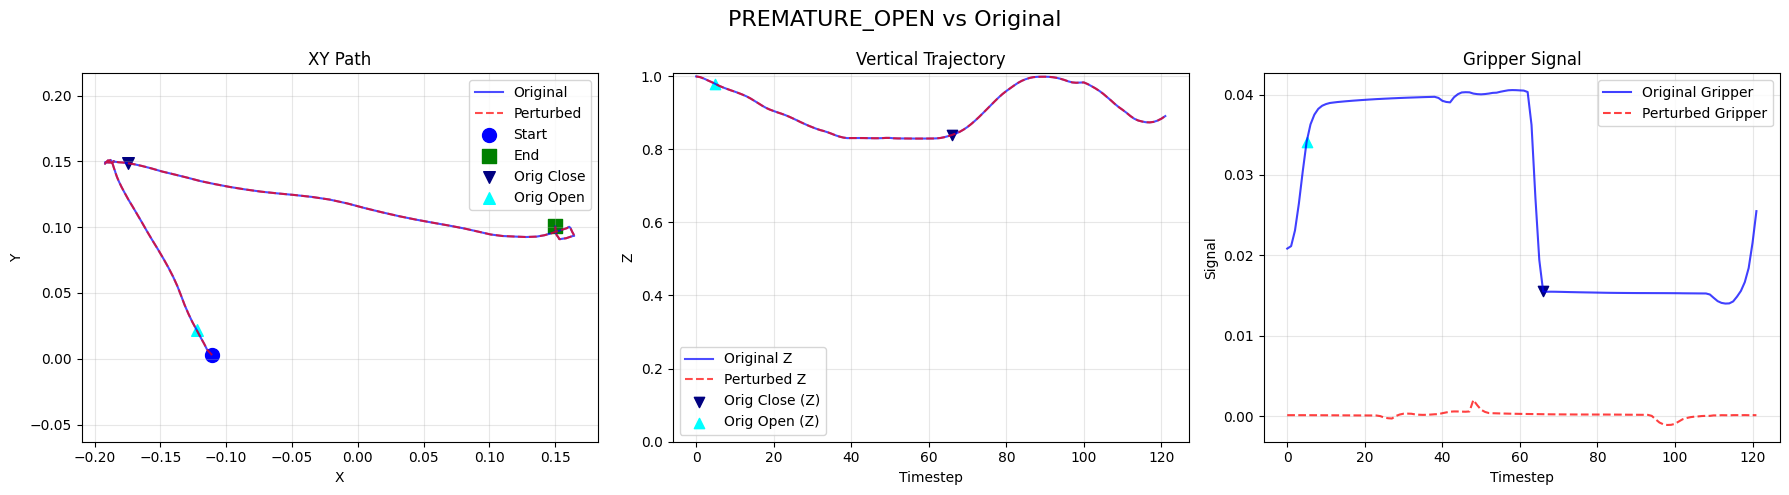

In [ ]:
from a2l_pr.utils.trajectory import TrajectoryAnalyzer
from a2l_pr.utils.visualization import visualize_trajectory_comparison

if vis_dict is not None:
    print(f"\n--- 3D Trajectory Plots for {vis_dict['demo_key']} ---")
    orig_traj = vis_dict['original']
    for name, pert_traj in vis_dict['perturbations'].items():
        visualize_trajectory_comparison(orig_traj, pert_traj, f"{name} vs Original")

        visualize_trajectory_comparison(
                orig_traj, 
                pert_traj, 
                title=f"{name} vs Original"
                )

## 5. Simulation Visualization of Recovery
We take the `vis_dict` saved from the validation set (unseen during training)
and use the trained model to predict recovery, then simulate it.

In [ ]:
if HAS_ROBOMIMIC and vis_dict is not None:
    print("\n--- Generating Recovery Simulation Videos on Validation Trajectory ---")
    
    # Load best model
    model.load_state_dict(torch.load("best_failure_recognizer.pth", map_location=device))
    model.eval()

    def render_trajectory_to_video(traj_dict, dataset_path, ep_name, output_path):
        if not os.path.exists(dataset_path): return False
        try:
            dummy_spec = dict(obs=dict(low_dim=["robot0_eef_pos"], rgb=[]))
            ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=dummy_spec)
            env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path)
            env = EnvUtils.create_env_from_metadata(env_meta=env_meta, render=False, render_offscreen=True)
            
            with h5py.File(dataset_path, 'r') as f:
                states = f[ep_name]['states'][()]
                initial_state = dict(states=states[0])
                if EnvUtils.is_robosuite_env(env_meta):
                    initial_state["model"] = f[ep_name].attrs["model_file"]
                    
            env.reset_to(initial_state)
            actions = traj_dict.get('actions', [])
            
            writer = imageio.get_writer(output_path, fps=20)
            for i in range(len(actions)):
                env.step(actions[i])
                if i % 5 == 0:
                    frame = env.render(mode="rgb_array", height=256, width=256, camera_name="agentview")
                    writer.append_data(frame)
            writer.close()
            return True
        except Exception as e:
            print(f"Render failed: {e}")
            return False

    OUTPUT_DIR = Path(os.getcwd()) / "output"
    OUTPUT_DIR.mkdir(exist_ok=True)
    # The keys in vis_dict are like 'demo_176', but HDF5 needs 'data/demo_176'
    ep_name = f"data/{vis_dict['demo_key']}"
    
    html_content = f"<h2>Validation Test: {ep_name}</h2><div style='display: flex; flex-direction: row; flex-wrap: wrap; justify-content: space-around;'>"
    
    for name, perturbed_traj in vis_dict['perturbations'].items():
        # Predict recovery
        sample = extract_learning_sample(perturbed_traj, failure_type_id=0)
        frames_np = sample['frames']
        N, C, H, W = frames_np.shape
        frames_np = frames_np.reshape((N * C, H, W))
        frames_tensor = torch.tensor(frames_np).unsqueeze(0).to(device)
        actions_tensor = torch.tensor(sample['actions']).unsqueeze(0).to(device)
        
        with torch.no_grad():
            outputs = model(frames_tensor, actions_tensor)
            pred_rec_params = outputs['recovery_params'][0].cpu().numpy()
            pred_failure_idx = torch.argmax(outputs['failure_logits'], dim=1).item()
        
        print(f"Evaluating {name}...")
        print(f" -> Predicted Failure Class: {pred_failure_idx} (Target > 0)")
        print(f" -> Predicted Recovery Params: {np.round(pred_rec_params, 3)}")
        
        recovered_actions = list(perturbed_traj.get('actions', []))
        
        # If it correctly recognized a failure, simulate the recovery
        # To make it visible, we execute the predicted delta parameters repeatedly.
        # If the model learned well, pred_rec_params should match the targets
        # we defined (e.g. +/- 0.05 for movement, +/- 1.0 for gripper).
        if pred_failure_idx != 0:
            for _ in range(30): # Add 30 steps of the recovery residual
                # Apply a clip/scaling if necessary to keep simulation stable
                stable_recovery = np.clip(pred_rec_params, -1.0, 1.0)
                recovered_actions.append(stable_recovery)
                
        recovered_traj_dict = {'actions': recovered_actions}
        
        # Render Failure
        fail_out = str(OUTPUT_DIR / f'full_train_{name}_failure.mp4')
        if render_trajectory_to_video(perturbed_traj, robomimic_hdf5_path, ep_name, fail_out):
            fail_b64 = b64encode(open(fail_out, "rb").read()).decode('ascii')
            html_content += f"""
            <div style='text-align: center; margin-bottom: 20px;'>
                <h3>Failure: {name}</h3>
                <video width='350' controls autoplay loop>
                    <source src='data:video/mp4;base64,{fail_b64}' type='video/mp4'>
                </video>
            </div>
            """
            
        # Render Recovery
        rec_out = str(OUTPUT_DIR / f'full_train_{name}_recovery.mp4')
        if render_trajectory_to_video(recovered_traj_dict, robomimic_hdf5_path, ep_name, rec_out):
            rec_b64 = b64encode(open(rec_out, "rb").read()).decode('ascii')
            
            border_color = "green" if pred_failure_idx != 0 else "red"
            title = "Recovery (Success)" if pred_failure_idx != 0 else "Recovery (Failed to Detect)"
            
            html_content += f"""
            <div style='text-align: center; margin-bottom: 20px; border: 2px solid {border_color};'>
                <h3>{title}</h3>
                <video width='350' controls autoplay loop>
                    <source src='data:video/mp4;base64,{rec_b64}' type='video/mp4'>
                </video>
            </div>
            """

    html_content += "</div>"
    display(HTML(html_content))
    print("\nVisualization Generation Complete!")

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/griffing52/miniconda3/envs/a2l/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)



--- Generating Recovery Simulation Videos on Validation Trajectory ---
Evaluating UNDERREACH_IDLE...
 -> Predicted Failure Class: 2 (Target > 0)
 -> Predicted Recovery Params: [ 0.045 -0.059  0.034  0.049  0.014 -0.021 -0.392]

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7
Evaluating PREMATURE_CLOSE...
 -> Predicted Failure Class: 2 (Target > 0)
 -> Predicted Recovery Params: [ 0.044 -0.048  0.039  0.053  0.014 -0.018 -0.372]

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7
Evaluating LATERAL_DRIFT...
 -> Predicted Failure Class: 2 (Target > 0)
 -> Predicted Recovery Params: [ 0.052 -0.063  0.035  0.042  0.01  


Visualization Generation Complete!
